# Obstacle Problem

We consider the steady Stokes problem defined by the following set of differential equations:

$$
\begin{cases}
  -2\mu\boldsymbol{\nabla \cdot} \boldsymbol{(\nabla_s u)} + \boldsymbol{\nabla} p = 0,
  \qquad&\text{in }\Omega, \\
  \boldsymbol{\nabla} \cdot \boldsymbol{u} = 0,
  \qquad &\text{in }\Omega, \\
  \boldsymbol{u} = (1-y^2) \boldsymbol{i}, \qquad&\text{on }(\Gamma_{\text{in}} := \{x= -1,\, -1\le y \le 1 \}), \\
  \left(\mu\boldsymbol{\nabla} \boldsymbol{u} - pI\right) \boldsymbol{n} = 0, \qquad&\text{on }(\Gamma_{\text{out}} := \{x=4,\, -1\le y \le 1\}), \\
  \boldsymbol{u} = \boldsymbol{0}, \qquad&\text{on }\partial\Omega \backslash (\Gamma_{\text{in}}\cup\Gamma_{\text{out}}), \\
\end{cases}
$$

where $\mu = 1.0$, $\boldsymbol{\nabla_s u} := \boldsymbol{\frac{1}{2}(\nabla u + (\nabla u)^\top)}$ and the spatial domain $\Omega:=(-1,4)\times(-1,1)$.

In [2]:
from problems.obstacle import generate_problem
from solvers import SolverFactory
from common import MethodType
from fenics import Constant, plot
from postprocessing import plot_velocity, plot_pressure, plot_combined

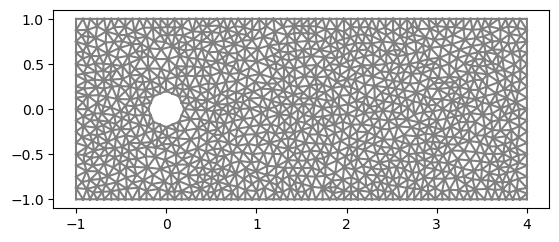

In [5]:
problem = generate_problem(n=32)
plot(problem.mesh)

Solving linear variational problem.


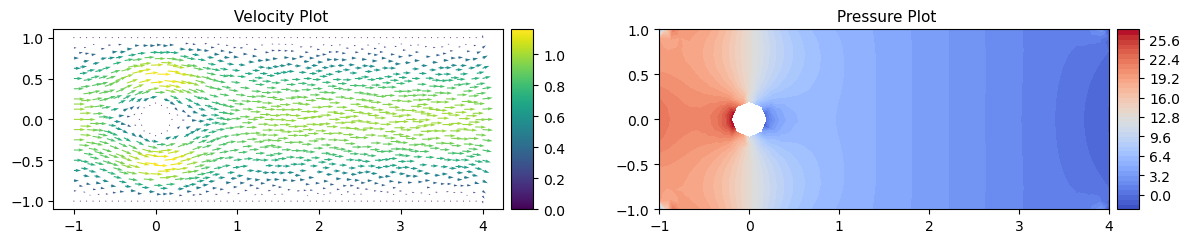

In [6]:
solver = SolverFactory.create_solver(MethodType.TH)
solution = solver.solve(problem, Constant(1.0))
ax = plot_combined(solution)

Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.


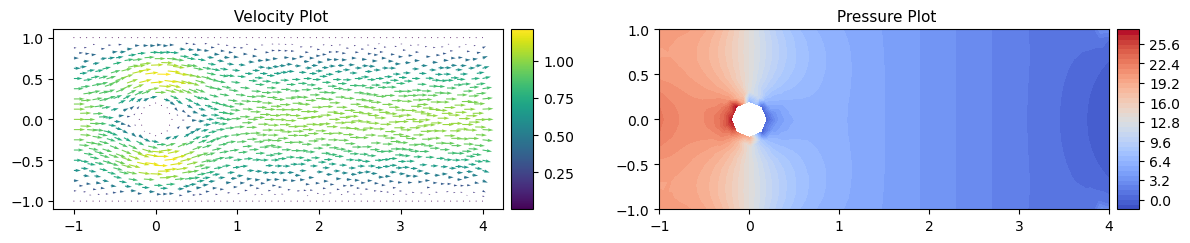

In [7]:
solver = SolverFactory.create_solver(MethodType.AUG)
solution = solver.solve(problem, Constant(1.0))

fig, _ = plot_combined(solution)